In [1]:
import json

import pandas as pd
import plotly.express as px

from utils.data import jp_500
from utils.datetime import date_string_to_quarter, get_current_quarter, get_quarter_end_date_string
from utils.datapath import (
    wins_signals_path,
    elo_signals_path,
    daily_prices_path
)
from utils.dummy import (
    generate_signals,
    sort_basket,
)

In [2]:
constituents = {
    get_quarter_end_date_string(quarter): basket for quarter, basket in jp_500.items()
}

black_list = ["2372"]
price_df = pd.read_csv(daily_prices_path)
price_df = price_df.drop(columns=["Unnamed: 0"] + black_list)

In [3]:
constituents_count = {
    quarter: len(basket) for quarter, basket in constituents.items()
}
# pd.Series(constituents_count)


In [4]:
price_df["Quarter"] = price_df["Date"].apply(date_string_to_quarter)
quarterly_price_df = price_df.ffill().drop_duplicates(subset="Quarter", keep="last").drop(columns="Date").set_index("Quarter")
quarterly_price_df = quarterly_price_df.drop([get_current_quarter()], axis=0)

In [6]:
# Average Weighted Basket Performance
jp_500

{'2015-Q2': ['7203',
  '8306',
  '4502',
  '8316',
  '9432',
  '9983',
  '9433',
  '9984',
  '2914',
  '8411',
  '7267',
  '4755',
  '6758',
  '9022',
  '6861',
  '6954',
  '3382',
  '9020',
  '7201',
  '6902',
  '4689',
  '6752',
  '6501',
  '8802',
  '8801',
  '6503',
  '7751',
  '6594',
  '4063',
  '8058',
  '4661',
  '7270',
  '8766',
  '4503',
  '6367',
  '5108',
  '4452',
  '6273',
  '4519',
  '5401',
  '7011',
  '7974',
  '4523',
  '8830',
  '6326',
  '6971',
  '2502',
  '6098',
  '4578',
  '8604',
  '6201',
  '7269',
  '8031',
  '8001',
  '8113',
  '6301',
  '9201',
  '7741',
  '6723',
  '9021',
  '9735',
  '8421',
  '4901',
  '4612',
  '8591',
  '8309',
  '9202',
  '6869',
  '7309',
  '3402',
  '8725',
  '1925',
  '9613',
  '8267',
  '4324',
  '7211',
  '5411',
  '1605',
  '4568',
  '6988',
  '4507',
  '2802',
  '7261',
  '7259',
  '7733',
  '5802',
  '8053',
  '6702',
  '6762',
  '9501',
  '8308',
  '2503',
  '9843',
  '5020',
  '8630',
  '9502',
  '4528',
  '3407',
  '4911',

In [ ]:
quarterly_price_df.apply(lambda x: x, axis=1)

Quarter
2014-Q1    3577
2014-Q2    3577
2014-Q3    3577
2014-Q4    3577
2015-Q1    3577
2015-Q2    3577
2015-Q3    3577
2015-Q4    3577
2016-Q1    3577
2016-Q2    3577
2016-Q3    3577
2016-Q4    3577
2017-Q1    3577
2017-Q2    3577
2017-Q3    3577
2017-Q4    3577
2018-Q1    3577
2018-Q2    3577
2018-Q3    3577
2018-Q4    3577
2019-Q1    3577
2019-Q2    3577
2019-Q3    3577
2019-Q4    3577
2020-Q1    3577
2020-Q2    3577
2020-Q3    3577
2020-Q4    3577
2021-Q1    3577
2021-Q2    3577
2021-Q3    3577
2021-Q4    3577
2022-Q1    3577
2022-Q2    3577
2022-Q3    3577
2022-Q4    3577
2023-Q1    3577
2023-Q2    3577
2023-Q3    3577
2023-Q4    3577
2024-Q1    3577
2024-Q2    3577
2024-Q3    3577
2024-Q4    3577
2025-Q1    3577
dtype: int64

In [15]:
jp_500_performance = {}
for quarter, basket in jp_500.items():
    jp_500_performance[quarter] = quarterly_price_df.loc[quarter][basket].sum()

<Axes: >

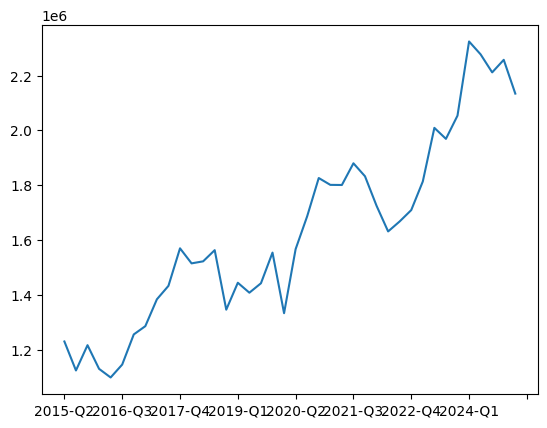

In [19]:
pd.Series(jp_500_performance).plot()